In [2]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Load both claims files
claims1 = pd.read_csv('/content/drive/MyDrive/94709- HM Cancer Utilization  Trajectories/Data/claims_staged_cmu_1_2.csv')
claims2 = pd.read_csv('/content/drive/MyDrive/94709- HM Cancer Utilization  Trajectories/Data/claims_staged_cmu_2_2.csv')

# Combine into one dataframe
claims = pd.concat([claims1, claims2], ignore_index=True)

print(f"Claims 1 shape: {claims1.shape}")
print(f"Claims 2 shape: {claims2.shape}")
print(f"Combined Claims shape: {claims.shape}")
claims.head()

Mounted at /content/drive
Claims 1 shape: (1258694, 24)
Claims 2 shape: (1258693, 24)
Combined Claims shape: (2517387, 24)


,PRI_DIAG_CD,ADM_DIAG_CD,DIAG_CD_001,DIAG_CD_002,DIAG_CD_003,HCPCS,DRG,Med_Cost_Category,NDC_CD,DRUG_NM,...,provider_number,ROUTE DESCRIPTION,STRENGTH DESCRIPTION,PROC_DESC,DIAG_DESC,DRG_DESC,ADM_DIAG_DESC,DIAG_001_DIAG_DESC,DIAG_002_DIAG_DESC,DIAG_003_DIAG_DESC
0,J431,NaN,NaN,NaN,NaN,94727,NaN,Prof PCP Procedures,NaN,NaN,...,NaN,NaN,NaN,Pulm function test by gas,Panlobular emphysema,NaN,NaN,NaN,NaN,NaN
1,J431,NaN,NaN,NaN,NaN,94060,NaN,Prof PCP Procedures,NaN,NaN,...,NaN,NaN,NaN,Evaluation of wheezing,Panlobular emphysema,NaN,NaN,NaN,NaN,NaN
2,J431,NaN,NaN,NaN,NaN,94060,NaN,OP Other,NaN,NaN,...,2236.0,NaN,NaN,Evaluation of wheezing,Panlobular emphysema,NaN,NaN,NaN,NaN,NaN
3,J431,NaN,NaN,NaN,NaN,94726,NaN,OP Other,NaN,NaN,...,2236.0,NaN,NaN,Pulm funct tst plethysmograp,Panlobular emphysema,NaN,NaN,NaN,NaN,NaN
4,J431,NaN,NaN,NaN,NaN,94729,NaN,OP Other,NaN,NaN,...,2236.0,NaN,NaN,Co/membane diffuse capacity,Panlobular emphysema,NaN,NaN,NaN,NaN,NaN


In [3]:
import pandas as pd
import numpy as np

BASE = '/content/drive/MyDrive/94709- HM Cancer Utilization  Trajectories/Data/'

# Raw files
claims_1 = pd.read_csv(BASE + 'claims_staged_cmu_1_2.csv')
claims_2 = pd.read_csv(BASE + 'claims_staged_cmu_2_2.csv')
staging_raw = pd.read_csv(BASE + 'staging_dataset_cmu 1.csv')

In [4]:
# Merge claims
claims = pd.concat([claims_1, claims_2], ignore_index=True)

# Drop sparse columns
claims.drop(columns=['DRG_DESC', 'DRG', 'ADM_DIAG_DESC', 'ADM_DIAG_CD'], inplace=True)

# Type fixes
claims['days_since_earliest_dt'] = claims['days_since_earliest_dt'].astype(int)
claims['c_allowed'] = claims['c_allowed'].astype(float)

# Clean primary diagnosis
claims['PRI_DIAG_CD'] = claims['PRI_DIAG_CD'].astype(str).str.strip().str.upper().str.replace('.', '', regex=False)
claims.loc[claims['PRI_DIAG_CD'] == 'NAN', 'PRI_DIAG_CD'] = np.nan
claims['ICD10_simple'] = claims['PRI_DIAG_CD'].str[:3]

# Clean procedure fields
claims['HCPCS'] = claims['HCPCS'].astype(str).str.strip().str.upper()
claims.loc[claims['HCPCS'] == 'NAN', 'HCPCS'] = np.nan
claims['PROC_DESC'] = claims['PROC_DESC'].astype(str).str.strip().str.upper()
claims.loc[claims['PROC_DESC'] == 'NAN', 'PROC_DESC'] = np.nan

# Clean secondary diagnoses
for col in ['DIAG_CD_001', 'DIAG_CD_002', 'DIAG_CD_003']:
    claims[col] = claims[col].astype(str).str.strip().str.upper().str.replace('.', '', regex=False)
    claims.loc[claims[col] == 'NAN', col] = np.nan

# Clean drug fields
claims['DRUG_NM'] = claims['DRUG_NM'].astype(str).str.strip().str.upper()
claims.loc[claims['DRUG_NM'] == 'NAN', 'DRUG_NM'] = np.nan

# Flag cancer-related claims
def is_cancer(row):
    for code in [row['PRI_DIAG_CD'], row['DIAG_CD_001'], row['DIAG_CD_002'], row['DIAG_CD_003']]:
        if isinstance(code, str) and code.startswith('C'):
            return True
    return False

claims['is_cancer_related'] = claims.apply(is_cancer, axis=1)

# Select final columns
claims = claims[[
    'member_number', 'days_since_earliest_dt',
    'c_allowed', 'C_UTIL_CT', 'Med_Cost_Category', 'is_cancer_related',
    'PRI_DIAG_CD', 'ICD10_simple', 'DIAG_DESC',
    'DIAG_CD_001', 'DIAG_CD_002', 'DIAG_CD_003',
    'DIAG_001_DIAG_DESC', 'DIAG_002_DIAG_DESC', 'DIAG_003_DIAG_DESC',
    'HCPCS', 'PROC_DESC',
    'NDC_CD', 'DRUG_NM', 'ROUTE DESCRIPTION', 'STRENGTH DESCRIPTION',
    'provider_number'
]]

print("Claims cleaned:", claims.shape)

Claims cleaned: (2517387, 22)


In [5]:
staging = staging_raw.copy()

# Remove members with multiple staging records
counts = staging['member_number'].value_counts()
staging = staging[staging['member_number'].isin(counts[counts == 1].index)]

# Most recent stage date
staging['most_recent_stage_date'] = staging[['MOST_RECENT_PATH_STAGE_DT', 'MOST_RECENT_CLINICAL_STAGE_DT']].max(axis=1)

# Stage group (prefer pathologic)
staging['stage_group'] = staging['PATHOLOGIC_STAGE_GROUP'].combine_first(staging['CLINICAL_STAGE_GROUP'])

# Keep only Stage I–IV
staging = staging[staging['stage_group'].str.startswith(('Stage I', 'Stage II', 'Stage III', 'Stage IV'), na=False)]

# Stage source
staging['stage_source'] = np.where(staging['PATHOLOGIC_STAGE_GROUP'].notna(), 'pathologic',
                           np.where(staging['CLINICAL_STAGE_GROUP'].notna(), 'clinical', None))

# Cancer type
staging['ICD10_simple'] = staging['ICD10_CODE'].str[:3]
cancer_map = {'C50': 'breast', 'C34': 'lung', 'C18': 'colorectal', 'C19': 'colorectal', 'C20': 'colorectal', 'C21': 'colorectal'}
staging['cancer_type'] = staging['ICD10_simple'].map(cancer_map)

# Simplified stage
staging['final_stage_simple'] = staging['stage_group'].str.extract(r'Stage (IV|III|II|I)')[0]

# Drop intermediate columns
staging.drop(columns=['MOST_RECENT_PATH_STAGE_DT', 'MOST_RECENT_CLINICAL_STAGE_DT', 'PATHOLOGIC_STAGE_GROUP', 'CLINICAL_STAGE_GROUP'], inplace=True)

# Standardize ICD10
staging['ICD10_CODE'] = staging['ICD10_CODE'].astype(str).str.strip().str.upper().str.replace('.', '', regex=False)

# Reorder
staging = staging[['member_number', 'ICD10_CODE', 'ICD10_simple', 'cancer_type', 'stage_group', 'final_stage_simple', 'stage_source', 'most_recent_stage_date']]

print("Staging cleaned:", staging.shape)

# ---- MERGE ----
claims_merged = claims.merge(staging, on='member_number', how='inner')
claims_merged['days_from_stage'] = claims_merged['days_since_earliest_dt'] - claims_merged['most_recent_stage_date']

print("Merged shape:", claims_merged.shape)
print("Unique members:", claims_merged['member_number'].nunique())
claims_merged.head()

Staging cleaned: (3392, 8)
Merged shape: (2310037, 30)
Unique members: 3392


,member_number,days_since_earliest_dt,c_allowed,C_UTIL_CT,Med_Cost_Category,is_cancer_related,PRI_DIAG_CD,ICD10_simple_x,DIAG_DESC,DIAG_CD_001,...,STRENGTH DESCRIPTION,provider_number,ICD10_CODE,ICD10_simple_y,cancer_type,stage_group,final_stage_simple,stage_source,most_recent_stage_date,days_from_stage
0,A001,-364,18.50,1.0,Prof PCP Procedures,False,J431,J43,Panlobular emphysema,NaN,...,NaN,NaN,C50111,C50,breast,Stage IIA,II,pathologic,203.0,-567.0
1,A001,-364,20.00,1.0,Prof PCP Procedures,False,J431,J43,Panlobular emphysema,NaN,...,NaN,NaN,C50111,C50,breast,Stage IIA,II,pathologic,203.0,-567.0
2,A001,-364,458.12,1.0,OP Other,False,J431,J43,Panlobular emphysema,NaN,...,NaN,2236.0,C50111,C50,breast,Stage IIA,II,pathologic,203.0,-567.0
3,A001,-364,0.00,0.0,OP Other,False,J431,J43,Panlobular emphysema,NaN,...,NaN,2236.0,C50111,C50,breast,Stage IIA,II,pathologic,203.0,-567.0
4,A001,-364,0.00,0.0,OP Other,False,J431,J43,Panlobular emphysema,NaN,...,NaN,2236.0,C50111,C50,breast,Stage IIA,II,pathologic,203.0,-567.0


In [11]:
# All colorectal claims (no cancer filter)
colorectal_all = claims_merged[claims_merged['cancer_type'] == 'colorectal'].copy()
colorectal_all = colorectal_all[colorectal_all['ICD10_simple_x'].isin(['C18','C19','C20','C21'])].copy()

# Cancer-related only
colorectal = colorectal_all[colorectal_all['is_cancer_related'] == True].copy()

cohorts = {
    "all_claims": colorectal_all,
    "cancer_related": colorectal
}

All claims: (115967, 31)
Cancer-related: (115967, 31)

Window distribution (all claims):
stage_time_window
pre_stage    30110
0_to_90      24178
post_90      61679
Name: count, dtype: int64
✅ All summaries computed

COHORT: all_claims

--- DRUG_NM (overall by stage) ---

Top DRUG_NM — Stage I


,DRUG_NM,n_claims,n_patients,total_cost,cost_per_patient,claims_per_patient,mean_claim_cost,cost_share_within_stage
0,VERZENIO,3,1,39541.090000,39541.090000,3.000000,13180.363333,0.817784
1,CAPECITABINE,20,1,8331.880000,8331.880000,20.000000,416.594000,0.172319
2,SUTAB,1,1,152.030000,152.030000,1.000000,152.030000,0.003144
3,SUPREP,1,1,103.060000,103.060000,1.000000,103.060000,0.002131
4,PROCHLORPERAZINE MALEA,4,3,80.502487,26.834162,1.333333,20.125622,0.001665
5,DIPHENOXYLATE-ATROPINE,2,1,51.340000,51.340000,2.000000,25.670000,0.001062
6,GABAPENTIN,3,2,49.160128,24.580064,1.500000,16.386709,0.001017
7,NEOMYCIN SULFATE,3,3,21.572925,7.190975,1.000000,7.190975,0.000446
8,OXYCODONE HCL,1,1,12.870000,12.870000,1.000000,12.870000,0.000266
9,METRONIDAZOLE,5,5,7.990737,1.598147,1.000000,1.598147,0.000165



Top DRUG_NM — Stage II


,DRUG_NM,n_claims,n_patients,total_cost,cost_per_patient,claims_per_patient,mean_claim_cost,cost_share_within_stage
10,CAPECITABINE,10,7,26229.342469,3747.048924,1.428571,2622.934247,0.913879
11,PROCHLORPERAZINE MALEA,34,20,782.538472,39.126924,1.700000,23.015837,0.027265
12,SOD SULF-POTASS SULF-M,3,3,264.888886,88.296295,1.000000,88.296295,0.009229
13,LOPERAMIDE,9,5,236.551896,47.310379,1.800000,26.283544,0.008242
14,OXYCODONE HCL,16,3,157.155946,52.385315,5.333333,9.822247,0.005476
15,POTASSIUM CHLORIDE,4,2,127.868378,63.934189,2.000000,31.967094,0.004455
16,PLENVU,1,1,121.260000,121.260000,1.000000,121.260000,0.004225
17,SUPREP,1,1,103.060000,103.060000,1.000000,103.060000,0.003591
18,ZOLPIDEM TARTRATE,14,1,96.656702,96.656702,14.000000,6.904050,0.003368
19,MIRTAZAPINE,2,1,86.100000,86.100000,2.000000,43.050000,0.003000



Top DRUG_NM — Stage III


...


  [0_to_90]


,provider_number,n_claims,n_patients,total_cost,cost_per_patient,mean_claim_cost,cost_share_within_window
100,2244.0,448,36,240378.692777,6677.185910,536.559582,0.197373
101,2236.0,310,24,167401.532287,6975.063845,540.004943,0.137452
102,7997.0,94,1,133932.359098,133932.359098,1424.812331,0.109971
103,2223.0,124,11,102941.935809,9358.357801,830.176902,0.084525
104,2283.0,195,13,86526.162742,6655.858672,443.723911,0.071046
105,2266.0,293,4,68798.037479,17199.509370,234.805589,0.056490
106,2281.0,274,15,56360.868238,3757.391216,205.696599,0.046278
107,7817.0,333,30,44821.298463,1494.043282,134.598494,0.036802
108,2267.0,1,1,32455.680000,32455.680000,32455.680000,0.026649
109,2270.0,17,1,30482.870523,30482.870523,1793.110031,0.025029



  [post_90]


,provider_number,n_claims,n_patients,total_cost,cost_per_patient,mean_claim_cost,cost_share_within_window
110,2254.0,1110,2,1.093335e+06,546667.506282,984.986498,0.238614
111,2244.0,1684,56,1.048743e+06,18727.558521,622.769167,0.228882
112,2236.0,1365,37,4.761871e+05,12869.921599,348.855018,0.103925
113,2242.0,447,3,3.404248e+05,113474.932646,761.576729,0.074296
114,7817.0,1895,40,2.490512e+05,6226.279028,131.425415,0.054354
115,7997.0,100,1,1.464944e+05,146494.444221,1464.944442,0.031972
116,2250.0,707,8,1.291626e+05,16145.324492,182.691083,0.028189
117,2283.0,1153,21,1.236347e+05,5887.365706,107.228690,0.026983
118,2281.0,1305,16,9.511320e+04,5944.574817,72.883676,0.020758
119,2266.0,1033,8,8.938413e+04,11173.016103,86.528682,0.019508


/tmp/ipykernel_4780/965507819.py:188: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


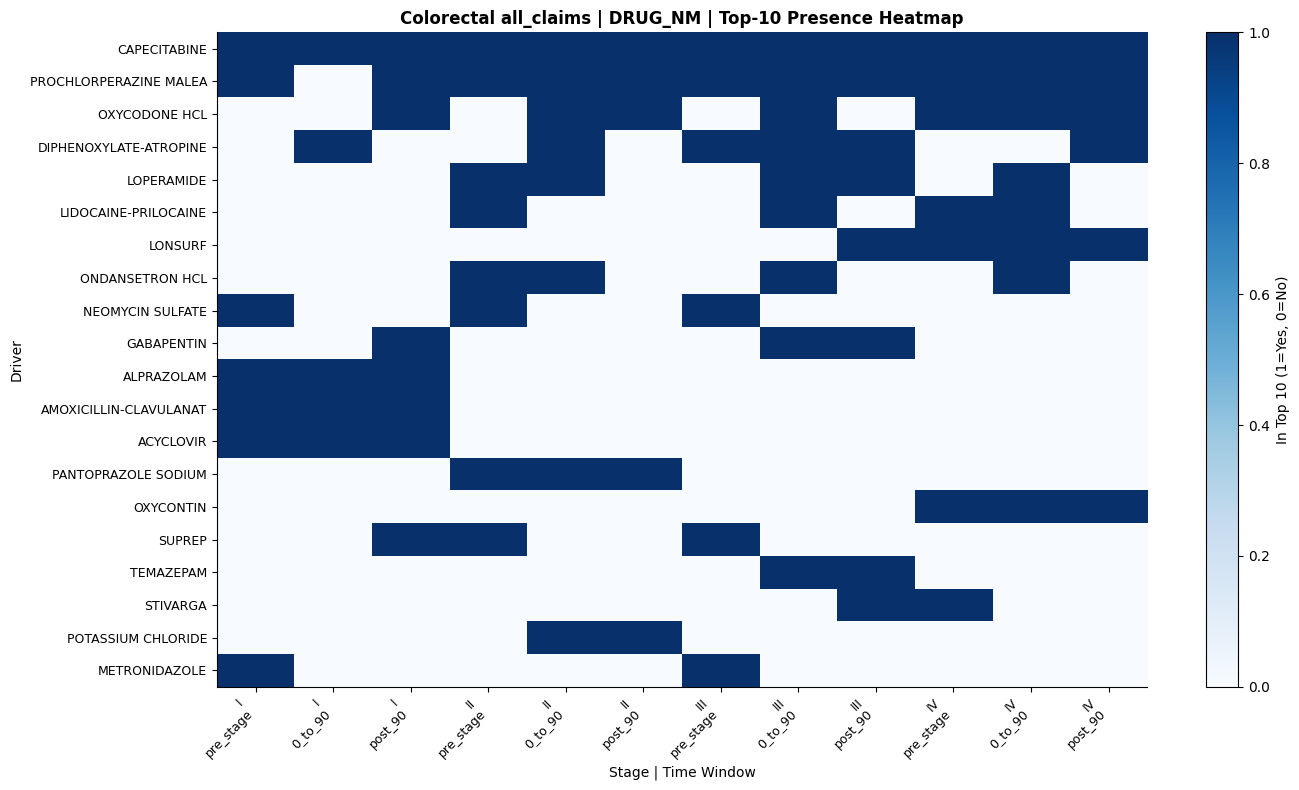

✅ Saved


/tmp/ipykernel_4780/965507819.py:188: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


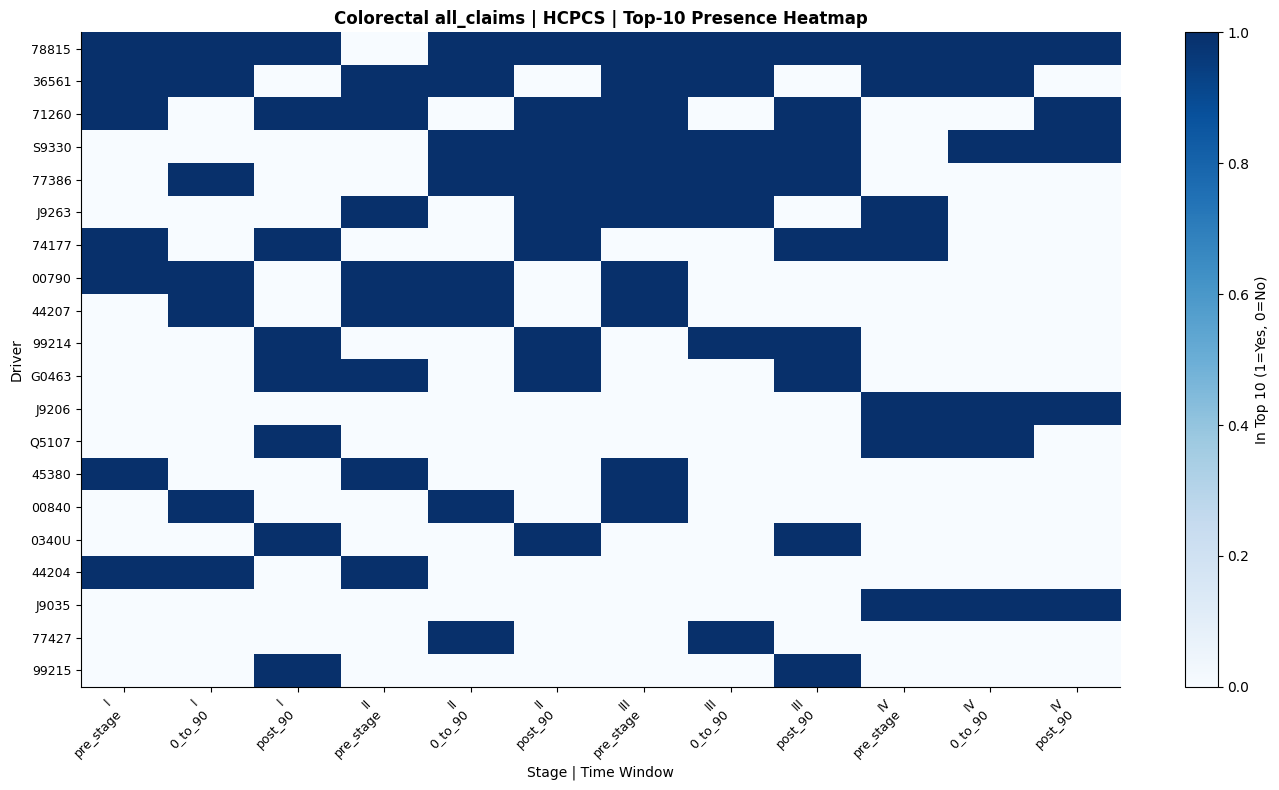

✅ Saved


/tmp/ipykernel_4780/965507819.py:188: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


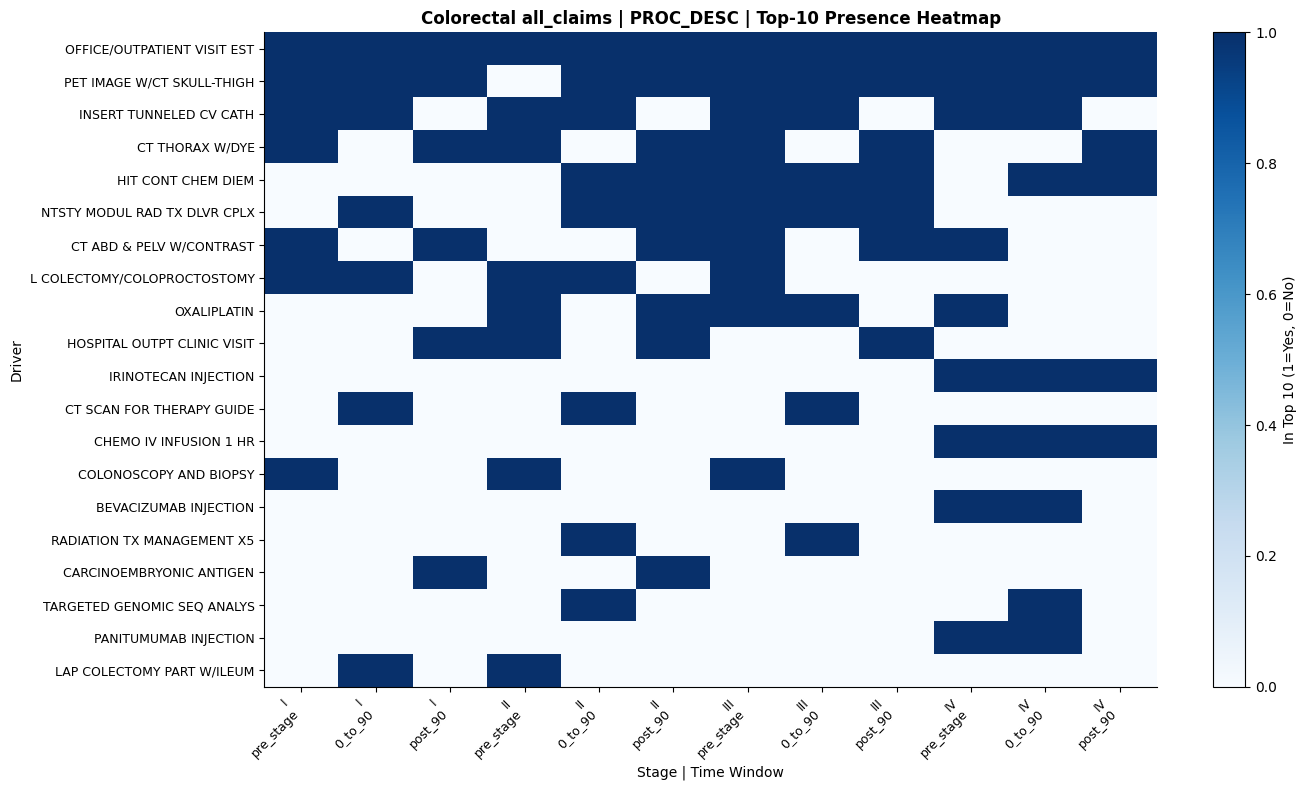

✅ Saved


/tmp/ipykernel_4780/965507819.py:188: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


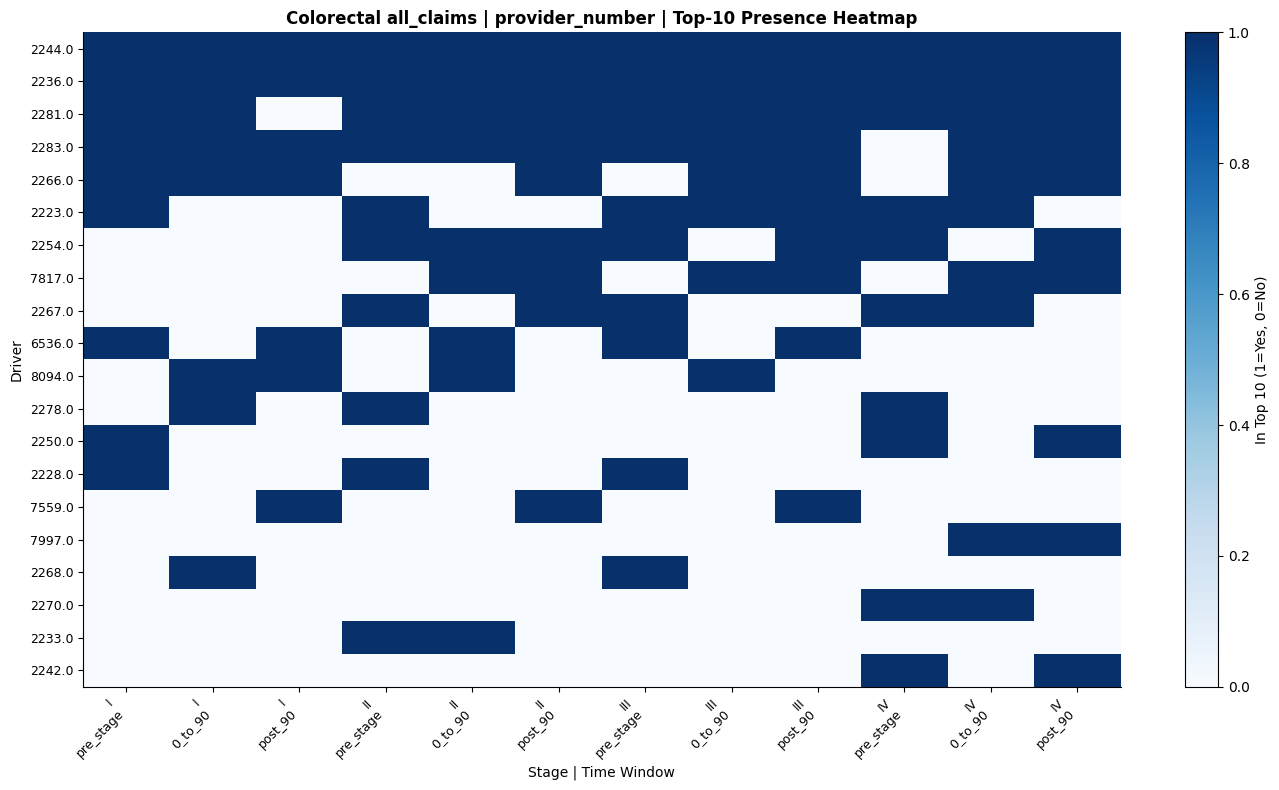

✅ Saved


/tmp/ipykernel_4780/965507819.py:188: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


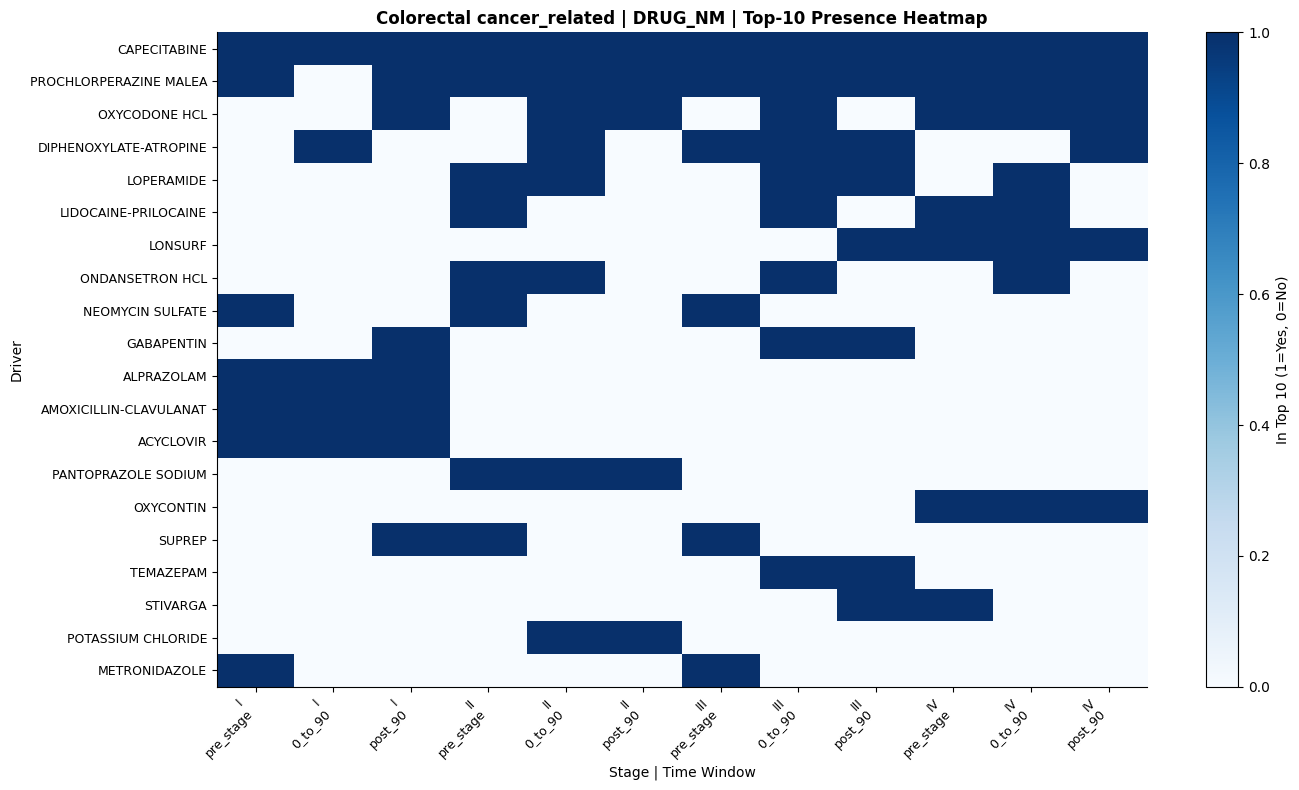

✅ Saved


/tmp/ipykernel_4780/965507819.py:188: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


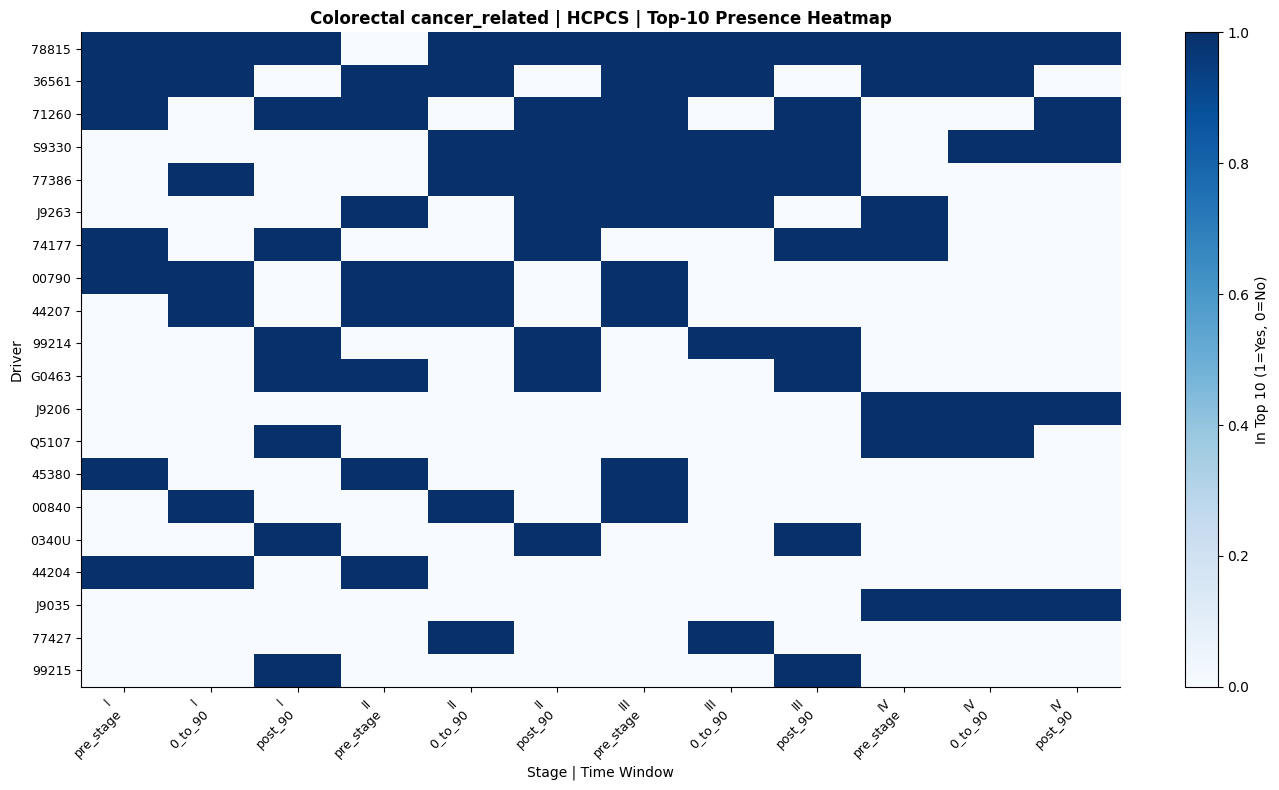

✅ Saved


/tmp/ipykernel_4780/965507819.py:188: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


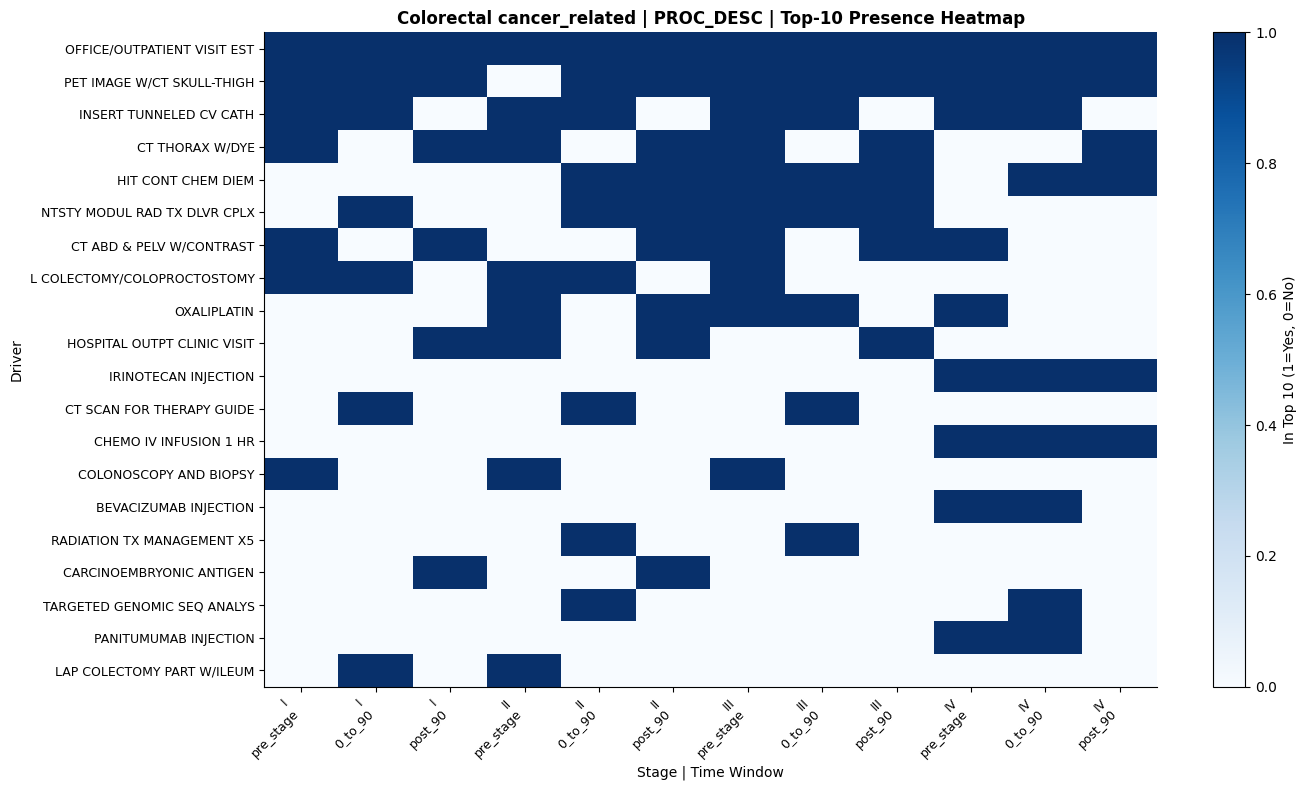

✅ Saved


/tmp/ipykernel_4780/965507819.py:188: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


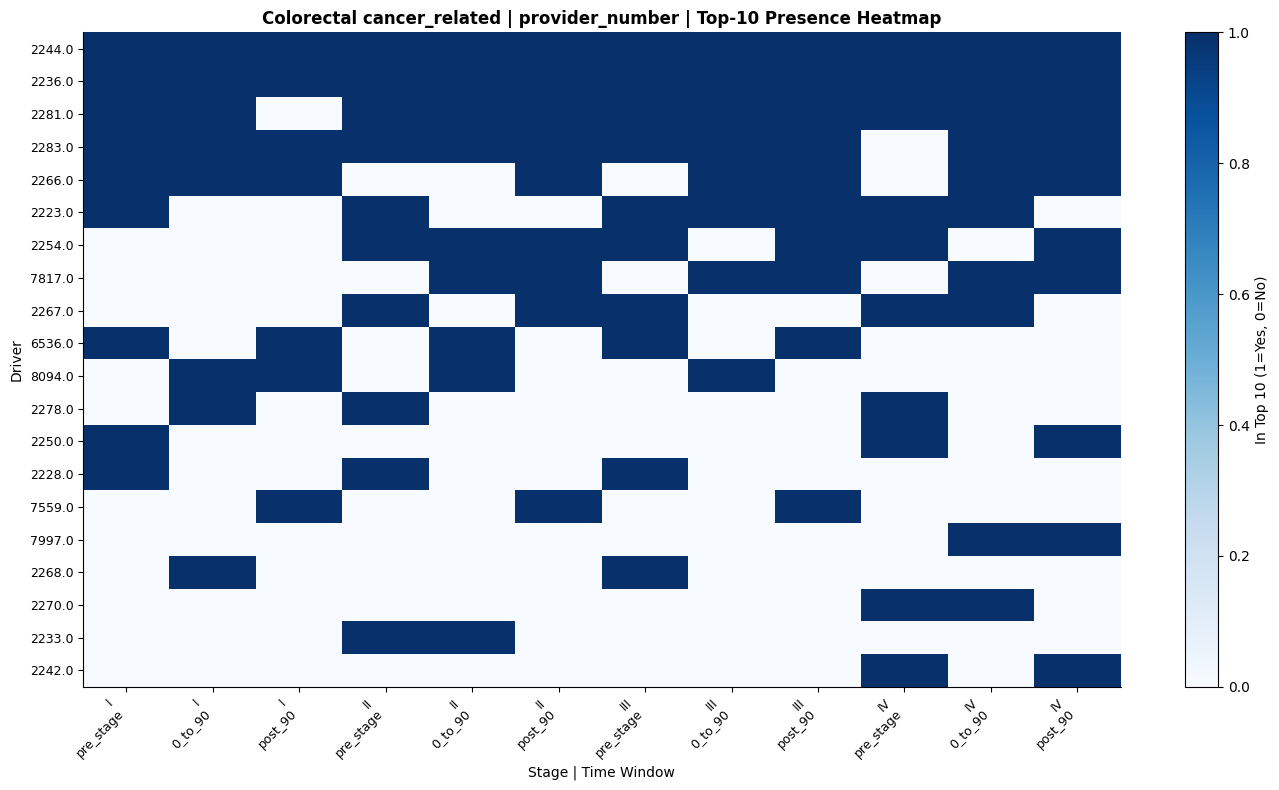

✅ Saved
✅ All CSVs exported


In [12]:
# ── COLORECTAL COST DRIVERS ──

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

driver_cols = ["DRUG_NM", "HCPCS", "PROC_DESC", "provider_number"]
stage_order = ["I", "II", "III", "IV"]
window_order = ["pre_stage", "0_to_90", "post_90"]

# ── Time windows relative to staging ─────────────────────────
colorectal["stage_time_window"] = np.select(
    [
        colorectal["days_from_stage"] < 0,
        (colorectal["days_from_stage"] >= 0) & (colorectal["days_from_stage"] <= 90),
        colorectal["days_from_stage"] > 90
    ],
    ["pre_stage", "0_to_90", "post_90"],
    default=None
)

colorectal["final_stage_simple"] = pd.Categorical(colorectal["final_stage_simple"], categories=stage_order, ordered=True)
colorectal["stage_time_window"] = pd.Categorical(colorectal["stage_time_window"], categories=window_order, ordered=True)

# ── Two cohorts ───────────────────────────────────────────────
colorectal_cancer_claims = colorectal[colorectal["is_cancer_related"] == True].copy()

cohorts = {
    "all_claims": colorectal,
    "cancer_related": colorectal_cancer_claims
}

print("All claims:", colorectal.shape)
print("Cancer-related:", colorectal_cancer_claims.shape)
print("\nWindow distribution (all claims):")
print(colorectal["stage_time_window"].value_counts(dropna=False).sort_index())

# ── Helper functions ──────────────────────────────────────────
def summarize_cost_drivers(df, group_col, stage_col="final_stage_simple", top_n=10):
    temp = df.copy()
    temp[group_col] = temp[group_col].astype(str).str.strip()
    temp = temp[
        temp[group_col].notna() &
        (temp[group_col] != "") &
        (temp[group_col].str.upper() != "NAN")
    ].copy()

    summary = (
        temp.groupby([stage_col, group_col], observed=False)
        .agg(
            n_claims=("member_number", "size"),
            n_patients=("member_number", "nunique"),
            total_cost=("c_allowed", "sum"),
            total_util=("C_UTIL_CT", "sum"),
            mean_claim_cost=("c_allowed", "mean"),
            median_claim_cost=("c_allowed", "median")
        )
        .reset_index()
    )

    summary["cost_per_patient"] = summary["total_cost"] / summary["n_patients"]
    summary["claims_per_patient"] = summary["n_claims"] / summary["n_patients"]

    stage_totals = (
        temp.groupby(stage_col, observed=False)["c_allowed"]
        .sum().rename("stage_total_cost").reset_index()
    )

    summary = summary.merge(stage_totals, on=stage_col, how="left")
    summary["cost_share_within_stage"] = summary["total_cost"] / summary["stage_total_cost"]
    summary["rank_within_stage"] = (
        summary.groupby(stage_col, observed=False)["total_cost"]
        .rank(method="first", ascending=False)
    )

    return (
        summary[summary["rank_within_stage"] <= top_n]
        .sort_values([stage_col, "rank_within_stage"])
        .reset_index(drop=True)
    )


def summarize_cost_drivers_by_time(df, group_col, top_n=10):
    temp = df.copy()
    temp[group_col] = temp[group_col].astype(str).str.strip()
    temp = temp[
        temp[group_col].notna() &
        (temp[group_col] != "") &
        (temp[group_col].str.upper() != "NAN") &
        temp["stage_time_window"].notna()
    ].copy()

    summary = (
        temp.groupby(["final_stage_simple", "stage_time_window", group_col], observed=False)
        .agg(
            n_claims=("member_number", "size"),
            n_patients=("member_number", "nunique"),
            total_cost=("c_allowed", "sum"),
            total_util=("C_UTIL_CT", "sum"),
            mean_claim_cost=("c_allowed", "mean"),
            median_claim_cost=("c_allowed", "median")
        )
        .reset_index()
    )

    summary["cost_per_patient"] = summary["total_cost"] / summary["n_patients"]
    summary["claims_per_patient"] = summary["n_claims"] / summary["n_patients"]

    window_totals = (
        temp.groupby(["final_stage_simple", "stage_time_window"], observed=False)["c_allowed"]
        .sum().rename("window_total_cost").reset_index()
    )

    summary = summary.merge(window_totals, on=["final_stage_simple", "stage_time_window"], how="left")
    summary["cost_share_within_window"] = summary["total_cost"] / summary["window_total_cost"]
    summary["rank_within_window"] = (
        summary.groupby(["final_stage_simple", "stage_time_window"], observed=False)["total_cost"]
        .rank(method="first", ascending=False)
    )

    return (
        summary[summary["rank_within_window"] <= top_n]
        .sort_values(["final_stage_simple", "stage_time_window", "rank_within_window"])
        .reset_index(drop=True)
    )


# ── Run all summaries ─────────────────────────────────────────
overall_summaries = {
    cohort_name: {col: summarize_cost_drivers(df, col, top_n=10) for col in driver_cols}
    for cohort_name, df in cohorts.items()
}

time_summaries = {
    cohort_name: {col: summarize_cost_drivers_by_time(df, col, top_n=10) for col in driver_cols}
    for cohort_name, df in cohorts.items()
}

print("✅ All summaries computed")


# ── Display functions ─────────────────────────────────────────
def display_top_drivers_by_stage(summary_df, driver_col, top_k=10):
    for stage in stage_order:
        print(f"\nTop {driver_col} — Stage {stage}")
        display(
            summary_df[summary_df["final_stage_simple"] == stage][
                [driver_col, "n_claims", "n_patients", "total_cost",
                 "cost_per_patient", "claims_per_patient",
                 "mean_claim_cost", "cost_share_within_stage"]
            ].head(top_k)
        )


def display_top_drivers_by_stage_and_window(summary_df, driver_col, top_k=10):
    for stage in stage_order:
        print(f"\n{'='*60}\nStage {stage}")
        for window in window_order:
            print(f"\n  [{window}]")
            display(
                summary_df[
                    (summary_df["final_stage_simple"] == stage) &
                    (summary_df["stage_time_window"] == window)
                ][[driver_col, "n_claims", "n_patients", "total_cost",
                   "cost_per_patient", "mean_claim_cost", "cost_share_within_window"]].head(top_k)
            )


# ── Print all results ─────────────────────────────────────────
for cohort_name, summaries in overall_summaries.items():
    print(f"\n{'='*80}\nCOHORT: {cohort_name}\n{'='*80}")
    for col in driver_cols:
        print(f"\n--- {col} (overall by stage) ---")
        display_top_drivers_by_stage(summaries[col], col)

for cohort_name, summaries in time_summaries.items():
    print(f"\n{'='*80}\nCOHORT: {cohort_name} — TIME WINDOWS\n{'='*80}")
    for col in driver_cols:
        print(f"\n--- {col} (by stage + time window) ---")
        display_top_drivers_by_stage_and_window(summaries[col], col)


# ── Heatmap: which drivers appear across stage x window ──────
def make_top_driver_matrix(summary_df, driver_col, top_k=10):
    matrix_numeric = (
        summary_df[["final_stage_simple", "stage_time_window", driver_col, "rank_within_window"]]
        .assign(in_top_k=lambda x: (x["rank_within_window"] <= top_k).astype(int))
        .pivot_table(
            index=driver_col,
            columns=["final_stage_simple", "stage_time_window"],
            values="in_top_k",
            fill_value=0
        )
    )
    matrix_numeric["n_stage_window_hits"] = matrix_numeric.sum(axis=1)
    return matrix_numeric.sort_values("n_stage_window_hits", ascending=False)


def plot_top_driver_heatmap(matrix_numeric, title="", top_n_rows=20, figsize=(14, 8)):
    plot_df = matrix_numeric.head(top_n_rows)
    heatmap_df = plot_df.drop(columns=["n_stage_window_hits"])

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(heatmap_df.values, aspect="auto", cmap="Blues")
    plt.colorbar(im, ax=ax, label="In Top 10 (1=Yes, 0=No)")
    ax.set_xticks(range(len(heatmap_df.columns)))
    ax.set_xticklabels(
        [f"{stage}\n{window}" for stage, window in heatmap_df.columns],
        rotation=45, ha="right", fontsize=9
    )
    ax.set_yticks(range(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Stage | Time Window")
    ax.set_ylabel("Driver")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_').replace('|','')}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved")


for cohort_name in ["all_claims", "cancer_related"]:
    for col in driver_cols:
        matrix = make_top_driver_matrix(time_summaries[cohort_name][col], col)
        plot_top_driver_heatmap(
            matrix,
            title=f"Colorectal {cohort_name} | {col} | Top-10 Presence Heatmap",
            top_n_rows=20
        )


# ── Export CSVs ───────────────────────────────────────────────
for cohort_name, summaries in overall_summaries.items():
    for col, df_out in summaries.items():
        df_out.to_csv(f"colorectal_{cohort_name}_{col.replace(' ','_')}_overall.csv", index=False)

for cohort_name, summaries in time_summaries.items():
    for col, df_out in summaries.items():
        df_out.to_csv(f"colorectal_{cohort_name}_{col.replace(' ','_')}_time.csv", index=False)

print("✅ All CSVs exported")